# Automobile Brand Dendrogram


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Update the display names for each brand
Brands = {
    'alfa-romero': 'Alfa Romeo', 'audi': 'Audi', 'bmw': 'BMW',
    'chevrolet': 'Chevrolet', 'dodge': 'Dodge', 'honda': 'Honda',
    'isuzu': 'Isuzu', 'jaguar': 'Jaguar', 'mazda': 'Mazda',
    'mercedes-benz': 'Mercedes-Benz', 'mercury': 'Mercury', 'mitsubishi': 'Mitsubishi',
    'nissan': 'Nissan', 'peugot': 'Peugeot', 'plymouth': 'Plymouth',
    'porsche': 'Porsche', 'renault':'Renault', 'saab':'Saab',
    'subaru': 'Subaru', 'toyota': 'Toyota', 'volkswagen':'Volkswagen', 'volvo': 'Volvo',
}

# Dataset link: https://archive.ics.uci.edu/dataset/10/automobile
columns = [
    'symboling','normalized-losses','make','fuel-type','aspiration',
    'num-of-doors','body-style','drive-wheels','engine-location',
    'wheel-base','length','width','height','curb-weight',
    'engine-type','num-of-cylinders','engine-size','fuel-system',
    'bore','stroke','compression-ratio','horsepower','peak-rpm',
    'city-mpg','highway-mpg','price'
]

df = pd.read_csv('imports-85.data', header=None, names=columns)

features = ['horsepower', 'city-mpg', 'highway-mpg', 'price']
df_feat = df[['make'] + features].copy()

# Replace missing values marked by '?' with the median
df_feat.replace('?', np.nan, inplace=True)
df_feat[features] = df_feat[features].astype(float)
df_feat[features] = df_feat[features].fillna(df_feat[features].median())

In [ ]:
# Z-normalization so features have equal weight in clustering
brand_avg = df_feat.groupby('make')[features].mean().reset_index()
X = brand_avg[features].values
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

labels_raw = brand_avg['make'].tolist()
labels_clean = [Brands.get(l, l.title()) for l in labels_raw]
brand_count = len(labels_raw)

# Chose ward linkage to use; tested single, complete, and average linkage as well
Z = linkage(X_norm, method='ward', metric='euclidean')

cluster_ids = fcluster(Z, t=4, criterion='maxclust')
brand_cluster = {labels_raw[i]: cluster_ids[i] for i in range(brand_count)}

# Cluster outlines
cluster_info = {
    1: {'label': 'Cluster A – Economy', 'bg': '#FFD6D6', 'text': '#8B0000'},
    2: {'label': 'Cluster B – Economy Outlier', 'bg': '#D6E8FF', 'text': '#003580'},
    3: {'label': 'Cluster C – Luxury/Premium', 'bg': '#FFF3CC', 'text': '#7A5800'},
    4: {'label': 'Cluster D – Performance', 'bg': '#D6F5D6', 'text': '#1A5200'},
}

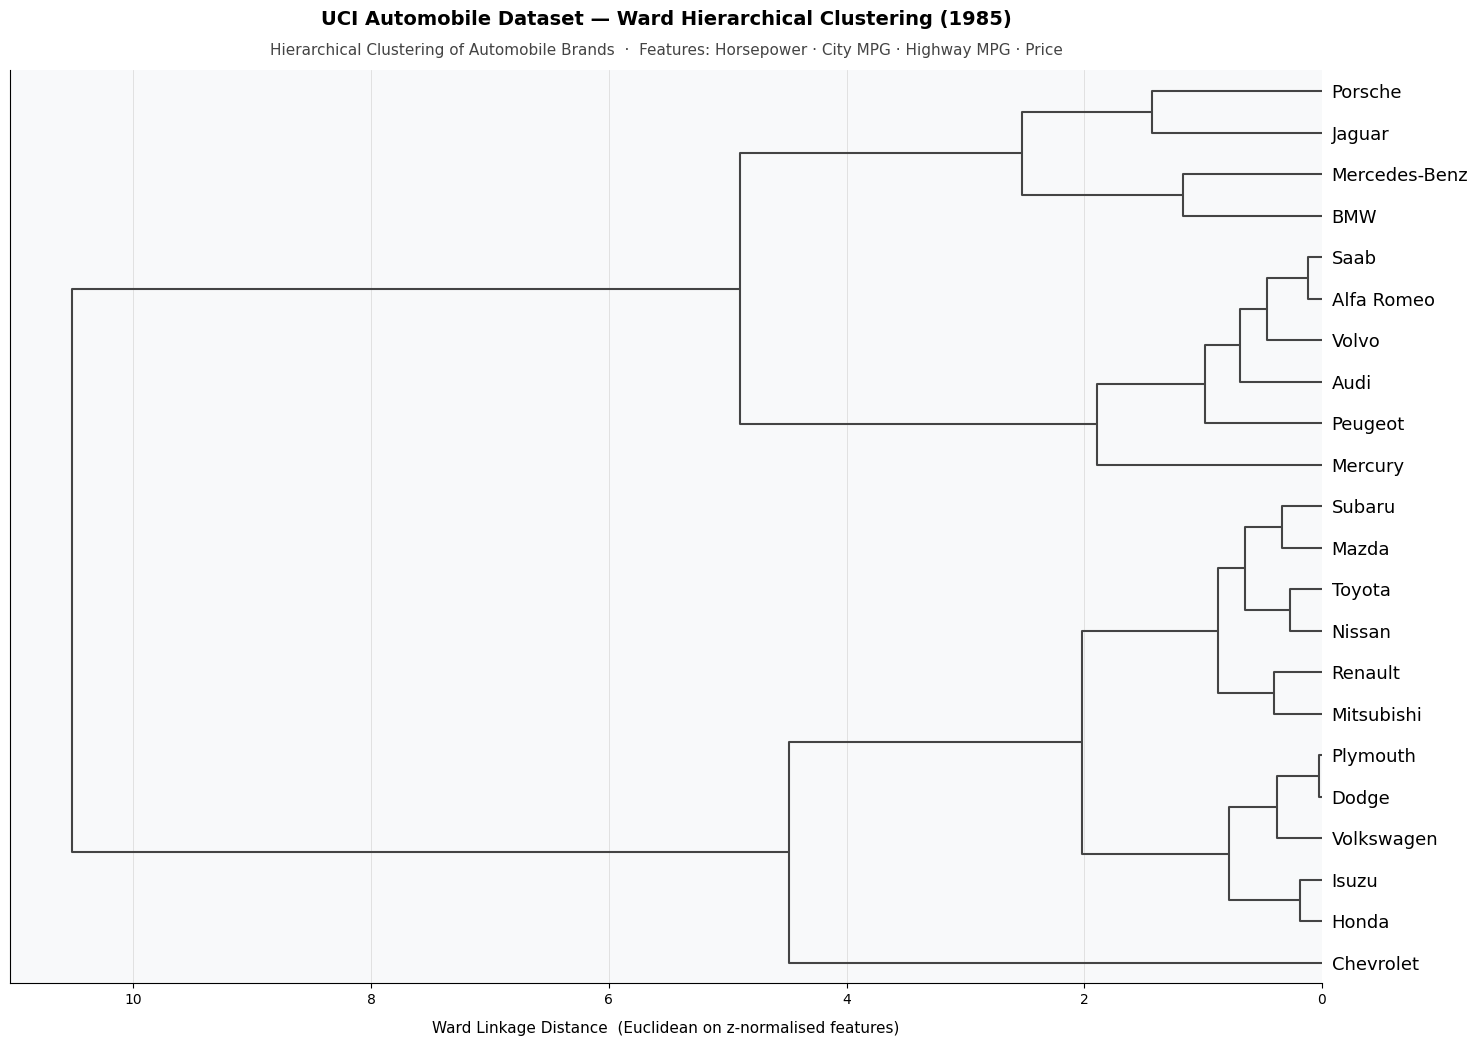

In [7]:
# Plot first dendrogram
dgram = plt.figure(figsize=(16, 11))
axis = dgram.add_axes([0.04, 0.09, 0.82, 0.83])
axis.set_facecolor('#F8F9FA')

data = dendrogram(
    Z,
    labels=labels_clean,
    orientation='left',
    leaf_font_size=13,
    color_threshold=0,
    link_color_func=lambda k: '#444444',
    ax=axis,
)

# Labels for the graph
axis.set_xlabel('Ward Linkage Distance  (Euclidean on z-normalised features)',
              fontsize=11, labelpad=10)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.grid(axis='x', color='#DDDDDD', linewidth=0.6, zorder=1)

cx = 0.04 + 0.82 / 2
dgram.text(cx, 0.975,
         'UCI Automobile Dataset — Ward Hierarchical Clustering (1985)',
         ha='center', va='top', fontsize=14, fontweight='bold')
dgram.text(cx, 0.945,
         'Hierarchical Clustering of Automobile Brands  ·  '
         'Features: Horsepower · City MPG · Highway MPG · Price',
         ha='center', va='top', fontsize=11, color='#444444')

plt.savefig('automobile_dendrogram.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

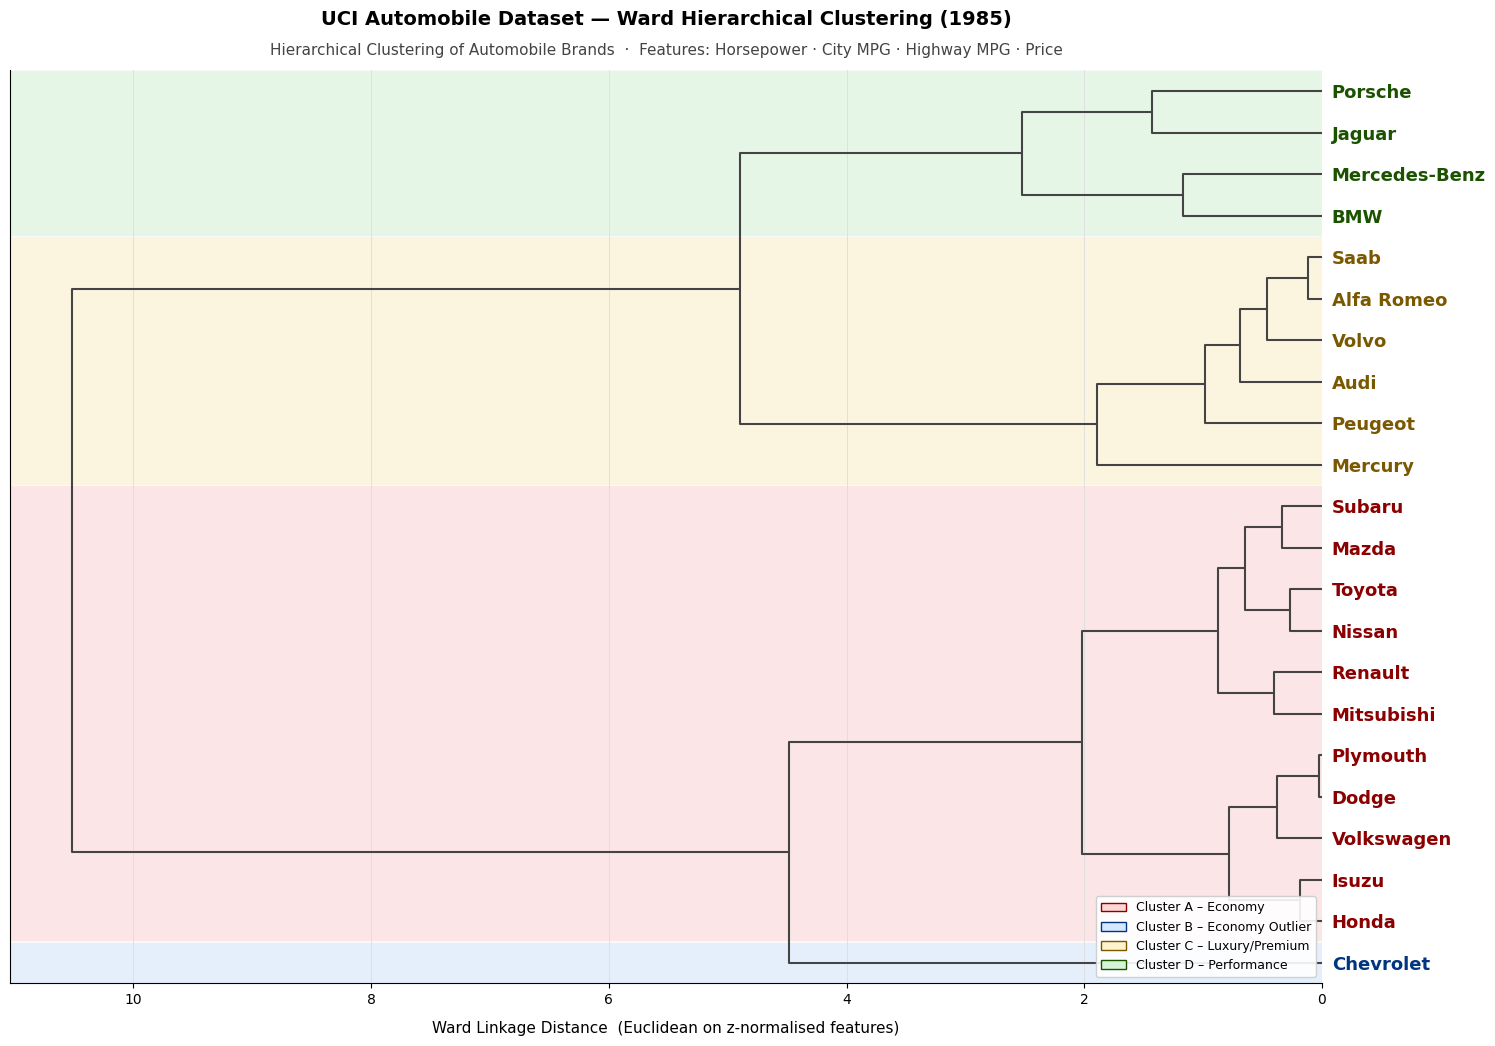

In [8]:
# Plot colored clustered dendrogram
dgram2 = plt.figure(figsize=(16, 11))
axis2 = dgram2.add_axes([0.04, 0.09, 0.82, 0.83])
axis2.set_facecolor('#F8F9FA')

data2 = dendrogram(
    Z,
    labels=labels_clean,
    orientation='left',
    leaf_font_size=13,
    color_threshold=0,
    link_color_func=lambda k: '#444444',
    ax=axis2,
)

leaf_order = data2['leaves']
leaf_ys = [5 + 10*i for i in range(brand_count)]
ordered_btop = [labels_raw[leaf_order[i]] for i in range(brand_count)]

# Finds the start and end ranges of each cluster in the leaf order
groups = []
cur_c, start = None, 0
for i, make in enumerate(ordered_btop):
    c = brand_cluster[make]
    if c != cur_c:
        if cur_c is not None:
            groups.append((cur_c, start, i - 1))
        cur_c, start = c, i
groups.append((cur_c, start, len(ordered_btop) - 1))

x_min, x_max = axis2.get_xlim()
for c_id, s, e in groups:
    y_lo = leaf_ys[s] - 4.8
    y_hi = leaf_ys[e] + 4.8
    axis2.add_patch(patches.Rectangle(
        [x_min, y_lo], x_max - x_min, y_hi - y_lo,
        facecolor=cluster_info[c_id]['bg'],
        edgecolor='none', alpha=0.55, zorder=0
    ))

# Color leaf label text by cluster
cap_to_raw = {v: k for k, v in Brands.items()}
for lbl in axis2.get_yticklabels():
    raw = cap_to_raw.get(lbl.get_text(), lbl.get_text().lower())
    cid = brand_cluster.get(raw, 1)
    lbl.set_color(cluster_info[cid]['text'])
    lbl.set_fontweight('bold')

# Labels for the graph
axis2.set_xlabel('Ward Linkage Distance  (Euclidean on z-normalised features)', fontsize=11, labelpad=10)
axis2.spines['top'].set_visible(False)
axis2.spines['right'].set_visible(False)
axis2.grid(axis='x', color='#DDDDDD', linewidth=0.6, zorder=1)

legend_patches = [
    patches.Patch(
        facecolor=cluster_info[k]['bg'],
        edgecolor=cluster_info[k]['text'],
        label=cluster_info[k]['label']
    )
    for k in sorted(cluster_info)
]
axis2.legend(handles=legend_patches, loc='lower right', fontsize=9,
          framealpha=0.9, edgecolor='#CCCCCC')

cx = 0.04 + 0.82 / 2
dgram2.text(cx, 0.975, 'UCI Automobile Dataset — Ward Hierarchical Clustering (1985)',
         ha='center', va='top', fontsize=14, fontweight='bold')
dgram2.text(cx, 0.945, 'Hierarchical Clustering of Automobile Brands  ·  '
         'Features: Horsepower · City MPG · Highway MPG · Price',
         ha='center', va='top', fontsize=11, color='#444444')

plt.savefig('automobile_dendrogram_annotated.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()